# Master's Thesis Notebook

This notebook is part of the **Master's Thesis (MSc Dissertation)**: **Fast Simulation of Neutrino Oscillations in Matter**.

**Author**  
Juan Ramon Diaz Santos <diazjuan@alumni.uv.es>

**Supervisors**  
Roberto Ruiz de Austri Bazan <rruiz@ific.uv.es>  
Michele Lucente <michele.lucente@unibo.it>

**Date**  
June 2026


# test5 io

Notebook equivalent of `tests/4_earth/test5_io.py`. The original Python test module remains the source of truth; this notebook imports it and runs each numerical test and diagnostic plot in its own cell for interactive inspection.

The notebook uses the shared TPeanuts output-root convention defined in section `2. Paths`. Generated `earth` test artifacts and figures are redirected to the notebook-specific `OUTPUT_DIR` under `OUTPUT_TEST_ROOT / "earth" / NOTEBOOK_STEM`.


## 1. Libraries and test module

This section locates the repository, imports the original `earth` test module, and reloads it so source changes are reflected when the notebook is rerun. The expected result is that the module imports without errors. Possible problems include running the notebook from outside the repository tree or missing import paths for the editable package.


In [1]:
from __future__ import annotations

import importlib
import importlib.util
import os
import sys
import traceback
from pathlib import Path

import matplotlib.pyplot as plt


from tpeanuts.util.notebooks import find_repo_root
HERE = Path.cwd().resolve()
PACKAGE_DIR = find_repo_root(HERE, folder="analysis")
print(f"PACKAGE_DIR = {PACKAGE_DIR}")

NOTEBOOK_STEM = "test5_io"
TEST_MODULE_PATH = PACKAGE_DIR / "notebooks" / "tests" / "4_earth" / f"{NOTEBOOK_STEM}.py"
TEST_MODULE_NAME = f"notebook_tests_{TEST_MODULE_PATH.parent.name.replace('.', '_')}_{NOTEBOOK_STEM}"
if not TEST_MODULE_PATH.exists():
    raise FileNotFoundError(f"Could not find local test module: {TEST_MODULE_PATH}")
spec = importlib.util.spec_from_file_location(TEST_MODULE_NAME, TEST_MODULE_PATH)
if spec is None or spec.loader is None:
    raise ImportError(f"Could not load test module spec from {TEST_MODULE_PATH}")
TEST_MODULE = importlib.util.module_from_spec(spec)
sys.modules[TEST_MODULE_NAME] = TEST_MODULE
spec.loader.exec_module(TEST_MODULE)
print("Loaded local test module:", TEST_MODULE_PATH)

from tpeanuts.util.notebooks import build_notebook_test_runner


PACKAGE_DIR = G:\Mi unidad\03.Codigo\034.TFM.UV\Tpeanuts
Loaded local test module: G:\Mi unidad\03.Codigo\034.TFM.UV\Tpeanuts\notebooks\tests\4_earth\test5_io.py


## 2. Paths

All outputs are rooted at `DEFAULT_OUTPUT_ROOT` unless `TPEANUTS_OUTPUT_ROOT` is defined in the environment. This notebook writes `earth` test figures and generated artifacts under `OUTPUT_TEST_ROOT / "earth" / NOTEBOOK_STEM`, while data, analysis, benchmark, and external roots follow the same shared structure used by the analysis notebooks.


In [2]:
DEFAULT_OUTPUT_ROOT = Path(r"V:\output")
OUTPUT_ROOT = Path(os.environ.get("TPEANUTS_OUTPUT_ROOT", DEFAULT_OUTPUT_ROOT))

OUTPUT_DATA_ROOT = Path(OUTPUT_ROOT / "data")
OUTPUT_ANALYSIS_ROOT = Path(OUTPUT_ROOT / "analysis")
OUTPUT_BENCHMARK_ROOT = Path(OUTPUT_ROOT / "benchmark")
OUTPUT_TEST_ROOT = Path(OUTPUT_ROOT / "test")

OUTPUT_DATA_ATMOSPHERE = Path(OUTPUT_DATA_ROOT / "atmosphere")
OUTPUT_DATA_SOLAR = Path(OUTPUT_DATA_ROOT / "solar")
OUTPUT_DATA_EXTERNAL = Path(OUTPUT_DATA_ROOT / "external")

OUTPUT_ANALYSIS_ATMOSPHERE = Path(OUTPUT_ANALYSIS_ROOT / "atmosphere")
OUTPUT_ANALYSIS_SOLAR = Path(OUTPUT_ANALYSIS_ROOT / "solar")
OUTPUT_ANALYSIS_EXTERNAL = Path(OUTPUT_ANALYSIS_ROOT / "external")

OUTPUT_DATA_MCEQ = Path(OUTPUT_DATA_ROOT / "mceq")
OUTPUT_DATA_HONDA = Path(OUTPUT_DATA_ROOT / "honda")

OUTPUT_DIR = OUTPUT_TEST_ROOT / "earth" / NOTEBOOK_STEM
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

SHOW_PLOTS = True
print("Output root     :", OUTPUT_ROOT)
print("Output directory:", OUTPUT_DIR)


Output root     : V:\output
Output directory: V:\output\test\earth\test5_io


In [3]:
NOTEBOOK_RUNNER_ATTRS = {}
if "RUN_REAL_DATA_ANALYSIS" in globals():
    NOTEBOOK_RUNNER_ATTRS["RUN_REAL_mceq_run1_analysis"] = RUN_REAL_DATA_ANALYSIS

runner = build_notebook_test_runner(
    TEST_MODULE,
    OUTPUT_DIR,
    show_plots=SHOW_PLOTS,
    auto_save_figures=True,
    extra_module_attrs=NOTEBOOK_RUNNER_ATTRS,
)
run_notebook_test = runner.run_test
run_notebook_call = runner.run_call


## Test: `test_extract_delta_columns`

**What is checked:** Extract delta columns behavior and numerical consistency.

**Expected result:** The expected result is a clean pass for these checks: Delta columns must be detected in table order.

**Possible problems:** a failed assertion usually indicates a numerical regression or an unexpected API change; earth-density, exposure-cache, or geometry convention changes can affect this check.


In [4]:
run_notebook_test(TEST_MODULE.test_extract_delta_columns)


Running test_extract_delta_columns ...

Delta-column extraction:
columns      : ['rj', 'alpha', 'beta', 'gamma', 'delta1', 'delta2']
delta columns: ['delta1', 'delta2']
------------------------------------------------------------------------------------------
PASSED: test_extract_delta_columns


## Test: `test_parse_density_table_polynomial_mode`

**What is checked:** Parse density table polynomial mode behavior and numerical consistency.

**Expected result:** The expected result is a clean pass for these checks: parse_density_table must return earthdensity; rj shape is correct; Two delta columns must produce shape (2, Ns); density tensors must be on the requested device; and additional consistency checks.

**Possible problems:** a failed assertion usually indicates a numerical regression or an unexpected API change; earth-density, exposure-cache, or geometry convention changes can affect this check.


In [5]:
run_notebook_test(TEST_MODULE.test_parse_density_table_polynomial_mode)


Running test_parse_density_table_polynomial_mode ...

Parsed polynomial density table:
type         : <class 'tpeanuts.earth.density.EarthDensity'>
rj           : tensor([2.5000000000e-01, 5.0000000000e-01, 7.5000000000e-01, 1.0000000000e+00], dtype=torch.float64)
alpha        : tensor([1.0000000000e+01, 8.0000000000e+00, 5.0000000000e+00, 2.0000000000e+00], dtype=torch.float64)
beta         : tensor([1.0000000000e+00, 5.0000000000e-01, 2.0000000000e-01, 1.0000000000e-01], dtype=torch.float64)
gamma        : tensor([1.0000000000e-01, 5.0000000000e-02, 2.0000000000e-02, 1.0000000000e-02], dtype=torch.float64)
deltas shape : (2, 4)
tabulated    : False
Checking: delta1 values are preserved
  actual shape  : (4,)
  expected shape: (4,)
  max abs diff  : 0.000000e+00
------------------------------------------------------------------------------------------
PASSED: test_parse_density_table_polynomial_mode


## Test: `test_parse_density_table_tabulated_mode_zeroes_higher_terms`

**What is checked:** Parse density table tabulated mode zeroes higher terms behavior and numerical consistency.

**Expected result:** The expected result is a clean pass for these checks: Tabulated mode must set tabulated=True; Tabulated deltas must be empty.

**Possible problems:** a failed assertion usually indicates a numerical regression or an unexpected API change; earth-density, exposure-cache, or geometry convention changes can affect this check.


In [6]:
run_notebook_test(TEST_MODULE.test_parse_density_table_tabulated_mode_zeroes_higher_terms)


Running test_parse_density_table_tabulated_mode_zeroes_higher_terms ...

Parsed tabulated density table:
beta        : tensor([0., 0., 0., 0.], dtype=torch.float64)
gamma       : tensor([0., 0., 0., 0.], dtype=torch.float64)
deltas shape: (0, 4)
tabulated   : True
Checking: Tabulated beta values are zero
  actual shape  : (4,)
  expected shape: (4,)
  max abs diff  : 0.000000e+00
Checking: Tabulated gamma values are zero
  actual shape  : (4,)
  expected shape: (4,)
  max abs diff  : 0.000000e+00
------------------------------------------------------------------------------------------
PASSED: test_parse_density_table_tabulated_mode_zeroes_higher_terms


## Test: `test_load_earth_density_from_csv_synthetic_and_real_files`

**What is checked:** Load earth density from csv synthetic and real files behavior and numerical consistency.

**Expected result:** The expected result is a clean pass for these checks: Real density rj must be one-dimensional; Real density file must contain shells; Real alpha values must be finite; Real shell radii must be sorted increasingly.

**Possible problems:** a failed assertion usually indicates a numerical regression or an unexpected API change; earth-density, exposure-cache, or geometry convention changes can affect this check.


In [7]:
run_notebook_test(TEST_MODULE.test_load_earth_density_from_csv_synthetic_and_real_files)


Running test_load_earth_density_from_csv_synthetic_and_real_files ...
Created temporary density CSV file: G:\Mi unidad\03.Codigo\034.TFM.UV\Tpeanuts\notebooks\tests\temp\synthetic_earth_density.csv

Loaded density CSV files:
synthetic rj shape: (4,)
real rj shape     : (5,)
real deltas shape : (0, 5)
real rj min/max   : 0.192 1.0
Checking: Synthetic rj values are loaded
  actual shape  : (4,)
  expected shape: (4,)
  max abs diff  : 0.000000e+00
------------------------------------------------------------------------------------------
PASSED: test_load_earth_density_from_csv_synthetic_and_real_files


## Test: `test_attach_csv_loader_to_density_class`

**What is checked:** Attach csv loader to density class behavior and numerical consistency.

**Expected result:** The expected result is a clean pass for these checks: EarthDensity must receive from_csv static method; EarthDensity.from_csv must return earthdensity.

**Possible problems:** a failed assertion usually indicates a numerical regression or an unexpected API change; earth-density, exposure-cache, or geometry convention changes can affect this check.


In [8]:
run_notebook_test(TEST_MODULE.test_attach_csv_loader_to_density_class)


Running test_attach_csv_loader_to_density_class ...
Created temporary density CSV file: G:\Mi unidad\03.Codigo\034.TFM.UV\Tpeanuts\notebooks\tests\temp\synthetic_earth_density_loader.csv

Attached CSV loader:
EarthDensity.from_csv: <function load_earth_density_from_csv at 0x000002D2D0B0CCA0>
loaded rj shape      : (4,)
------------------------------------------------------------------------------------------
PASSED: test_attach_csv_loader_to_density_class


## Test: `test_read_and_convert_exposure_csv_modes`

**What is checked:** Read and convert exposure csv modes behavior and numerical consistency.

**Expected result:** The expected result is a clean pass for these checks: CosZenith conversion preserves shape; CosZenith conversion must be finite; CosZenith conversion must be non-negative after clamping.

**Possible problems:** a failed assertion usually indicates a numerical regression or an unexpected API change; earth-density, exposure-cache, or geometry convention changes can affect this check.


In [9]:
run_notebook_test(TEST_MODULE.test_read_and_convert_exposure_csv_modes)


Running test_read_and_convert_exposure_csv_modes ...
Created temporary exposure CSV file: G:\Mi unidad\03.Codigo\034.TFM.UV\Tpeanuts\notebooks\tests\temp\synthetic_exposure_modes.csv

Exposure CSV angle conversion:
raw      : tensor([1.0000000000e+00, 1.1250000000e+00, 1.2500000000e+00, 1.3750000000e+00, 1.5000000000e+00, 1.6250000000e+00, 1.7500000000e+00, 1.8750000000e+00, 2.0000000000e+00],
       dtype=torch.float64)
nadir    : tensor([1.0000000000e+00, 1.1250000000e+00, 1.2500000000e+00, 1.3750000000e+00, 1.5000000000e+00, 1.6250000000e+00, 1.7500000000e+00, 1.8750000000e+00, 2.0000000000e+00],
       dtype=torch.float64)
zenith   : tensor([2.0000000000e+00, 1.8750000000e+00, 1.7500000000e+00, 1.6250000000e+00, 1.5000000000e+00, 1.3750000000e+00, 1.2500000000e+00, 1.1250000000e+00, 1.0000000000e+00],
       dtype=torch.float64)
coszenith: tensor([0.0000000000e+00, 6.2399641119e-01, 1.2733820201e+00, 1.8991596805e+00, 2.3561944902e+00, 2.4545200477e+00, 2.0587801835e+00, 1.17935677

## Test: `test_nadir_exposure_from_csv_daynight_slices`

**What is checked:** Nadir exposure from csv daynight slices behavior and numerical consistency.

**Expected result:** The expected result is a clean pass for these checks: Full CSV exposure must keep all points; Night CSV slice must keep lower half for ns=9; Day CSV slice must keep upper half for ns=9.

**Possible problems:** a failed assertion usually indicates a numerical regression or an unexpected API change; earth-density, exposure-cache, or geometry convention changes can affect this check.


In [10]:
run_notebook_test(TEST_MODULE.test_nadir_exposure_from_csv_daynight_slices)


Running test_nadir_exposure_from_csv_daynight_slices ...
Created temporary exposure CSV file: G:\Mi unidad\03.Codigo\034.TFM.UV\Tpeanuts\notebooks\tests\temp\synthetic_exposure_daynight.csv

Nadir exposure CSV day/night slices:
full eta/exposure shapes : (9,) (9,)
night eta/exposure shapes: (4,) (4,)
day eta/exposure shapes  : (4,) (4,)
night exposure: tensor([1.0000000000e+00, 2.0000000000e+00, 3.0000000000e+00, 4.0000000000e+00], dtype=torch.float64)
day exposure  : tensor([6.0000000000e+00, 7.0000000000e+00, 8.0000000000e+00, 9.0000000000e+00], dtype=torch.float64)
Checking: Night exposure slice is the lower half
  actual shape  : (4,)
  expected shape: (4,)
  max abs diff  : 0.000000e+00
Checking: Day exposure slice is the upper half
  actual shape  : (4,)
  expected shape: (4,)
  max abs diff  : 0.000000e+00
------------------------------------------------------------------------------------------
PASSED: test_nadir_exposure_from_csv_daynight_slices


## Test: `test_nadir_exposure_cache_roundtrip`

**What is checked:** Nadir exposure cache roundtrip behavior and numerical consistency.

**Expected result:** The expected result is a clean pass for these checks: Cache save path must match deterministic cache filename; Cache file must exist after saving.

**Possible problems:** a failed assertion usually indicates a numerical regression or an unexpected API change; earth-density, exposure-cache, or geometry convention changes can affect this check.


In [11]:
run_notebook_test(TEST_MODULE.test_nadir_exposure_cache_roundtrip)


Running test_nadir_exposure_cache_roundtrip ...

Nadir exposure cache roundtrip:
saved path   : G:\Mi unidad\03.Codigo\034.TFM.UV\Tpeanuts\notebooks\tests\temp\cache\nadir_exposure_lam0.72000000_d0.000-365.000_ns11_dnall.pt
expected path: G:\Mi unidad\03.Codigo\034.TFM.UV\Tpeanuts\notebooks\tests\temp\cache\nadir_exposure_lam0.72000000_d0.000-365.000_ns11_dnall.pt
eta loaded   : tensor([0.0000000000e+00, 3.1415926536e-01, 6.2831853072e-01, 9.4247779608e-01, 1.2566370614e+00, 1.5707963268e+00, 1.8849555922e+00, 2.1991148575e+00, 2.5132741229e+00, 2.8274333882e+00,
        3.1415926536e+00], dtype=torch.float64)
W loaded     : tensor([5.0000000000e-01, 5.9549150281e-01, 8.4549150281e-01, 1.1545084972e+00, 1.4045084972e+00, 1.5000000000e+00, 1.4045084972e+00, 1.1545084972e+00, 8.4549150281e-01, 5.9549150281e-01,
        5.0000000000e-01], dtype=torch.float64)
Checking: Cached eta values roundtrip
  actual shape  : (11,)
  expected shape: (11,)
  max abs diff  : 0.000000e+00
Checking: Cach

## Test: `test_invalid_io_inputs_raise_errors`

**What is checked:** Invalid io inputs raise errors behavior and numerical consistency.

**Expected result:** The expected result is that the cell completes without raising an exception.

**Possible problems:** a failed assertion usually indicates a numerical regression or an unexpected API change; earth-density, exposure-cache, or geometry convention changes can affect this check.


In [12]:
run_notebook_test(TEST_MODULE.test_invalid_io_inputs_raise_errors)


Running test_invalid_io_inputs_raise_errors ...

Invalid IO input checks:
Missing density file should raise FileNotFoundError
Exposure CSV without 'Exposure' column should raise ValueError
Unknown CSV angle mode should raise ValueError
Missing cache file should raise FileNotFoundError
------------------------------------------------------------------------------------------
PASSED: test_invalid_io_inputs_raise_errors


## Plot: `plot_loaded_density_coefficients()`

**What is checked:** Loaded density coefficients behavior and numerical consistency.

**Expected result:** The expected result is that the plot call writes its diagnostic image file(s) (earth_io_density_coefficients.png) to `OUTPUT_DIR` and displays them inline when `SHOW_PLOTS = True`.

**Possible problems:** a failed assertion usually indicates a numerical regression or an unexpected API change; earth-density, exposure-cache, or geometry convention changes can affect this check; missing or blank plots may indicate a path, backend, or non-finite numerical-data problem.


### Plot output for `plot_loaded_density_coefficients()`

This block generates or validates diagnostic plot files in `OUTPUT_DIR`:

- `earth_io_density_coefficients.png`

The expected result is that each image is written to disk and, when `SHOW_PLOTS = True`, also displayed inline in the notebook. Possible problems include a non-writable output directory, an inactive Matplotlib backend, or upstream numerical values that make the plotted curves empty or non-finite.


Running plot_loaded_density_coefficients() ...
Saved plot: V:\output\test\earth\test5_io\plot_loaded_density_coefficients_figure_001.png


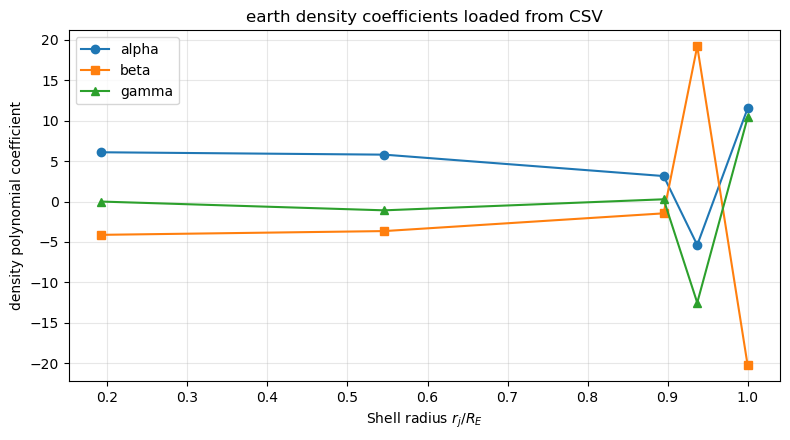

PASSED: plot_loaded_density_coefficients()


In [13]:
run_notebook_call('plot_loaded_density_coefficients()', lambda: TEST_MODULE.plot_loaded_density_coefficients())


## Plot: `plot_exposure_csv_modes()`

**What is checked:** Exposure csv modes behavior and numerical consistency.

**Expected result:** The expected result is that the plot call writes its diagnostic image file(s) (earth_io_exposure_csv_modes.png) to `OUTPUT_DIR` and displays them inline when `SHOW_PLOTS = True`.

**Possible problems:** a failed assertion usually indicates a numerical regression or an unexpected API change; earth-density, exposure-cache, or geometry convention changes can affect this check; missing or blank plots may indicate a path, backend, or non-finite numerical-data problem.


### Plot output for `plot_exposure_csv_modes()`

This block generates or validates diagnostic plot files in `OUTPUT_DIR`:

- `earth_io_exposure_csv_modes.png`

The expected result is that each image is written to disk and, when `SHOW_PLOTS = True`, also displayed inline in the notebook. Possible problems include a non-writable output directory, an inactive Matplotlib backend, or upstream numerical values that make the plotted curves empty or non-finite.


Running plot_exposure_csv_modes() ...
Created temporary exposure CSV file: G:\Mi unidad\03.Codigo\034.TFM.UV\Tpeanuts\notebooks\tests\temp\synthetic_exposure_plot_modes.csv
Saved plot: V:\output\test\earth\test5_io\plot_exposure_csv_modes_figure_001.png


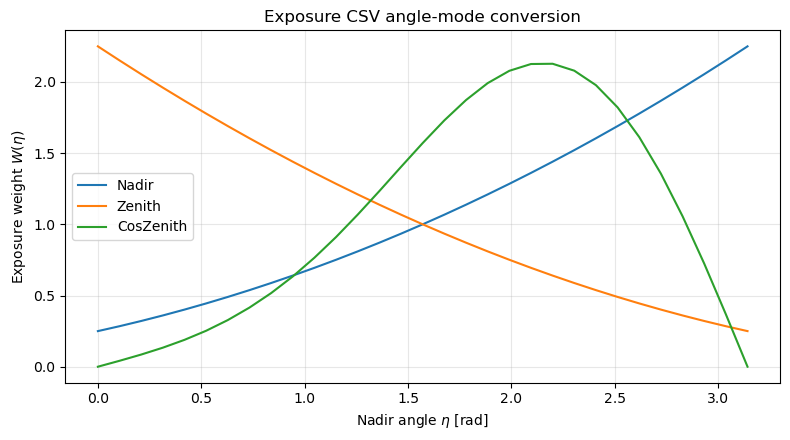

PASSED: plot_exposure_csv_modes()


In [14]:
run_notebook_call('plot_exposure_csv_modes()', lambda: TEST_MODULE.plot_exposure_csv_modes())


## Plot: `plot_cache_roundtrip_exposure()`

**What is checked:** Cache roundtrip exposure behavior and numerical consistency.

**Expected result:** The expected result is that the plot call writes its diagnostic image file(s) (earth_io_cache_roundtrip.png) to `OUTPUT_DIR` and displays them inline when `SHOW_PLOTS = True`.

**Possible problems:** a failed assertion usually indicates a numerical regression or an unexpected API change; earth-density, exposure-cache, or geometry convention changes can affect this check; missing or blank plots may indicate a path, backend, or non-finite numerical-data problem.


### Plot output for `plot_cache_roundtrip_exposure()`

This block generates or validates diagnostic plot files in `OUTPUT_DIR`:

- `earth_io_cache_roundtrip.png`

The expected result is that each image is written to disk and, when `SHOW_PLOTS = True`, also displayed inline in the notebook. Possible problems include a non-writable output directory, an inactive Matplotlib backend, or upstream numerical values that make the plotted curves empty or non-finite.


Running plot_cache_roundtrip_exposure() ...
Saved plot: V:\output\test\earth\test5_io\plot_cache_roundtrip_exposure_figure_001.png


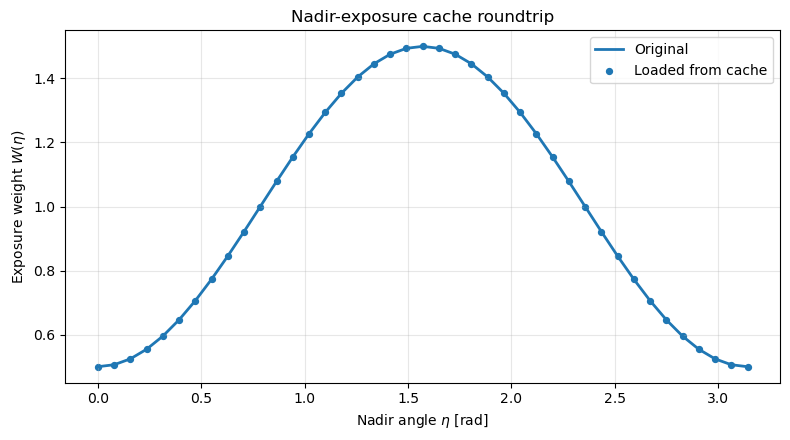

PASSED: plot_cache_roundtrip_exposure()


In [15]:
run_notebook_call('plot_cache_roundtrip_exposure()', lambda: TEST_MODULE.plot_cache_roundtrip_exposure())
